# Bayesian Optimization for Random Forest Hyperparameter Tuning
## 1. Research question
**Under the same 20-evaluation budget, which search strategy finds a strong Random Forest configuration more efficiently?**

This experiment compares Random Search with Bayesian Optimization on the Breast Cancer Wisconsin classification dataset. Mean five-fold cross-validation accuracy is the selection objective. Final performance is interpreted through **Quality, Efficiency, Reliability, and Practicality**.

## 2. Experimental design and fairness controls

| Control | Fixed before evaluation |
|:--|:--|
| Data and split | One stratified 80/20 split, seed 42 |
| Selection data | Training portion only |
| Objective | Mean accuracy across the same five stratified CV folds |
| Seeds | 42 for split, folds, forest, random sampling, and Bayesian optimizer |
| Search budget | Random Search: 20; Bayesian Optimization: 5 initialization + 15 EI = 20 |
| Shared search space | Same four parameters, types, bounds, and interpretation |
| Winner rule | Highest unrounded mean CV accuracy; exact ties go to the earliest trial |
| Final test | After both winners are saved, refit and predict once per final model |
| Practical metrics | Time, tree nodes, serialized size; secondary to CV accuracy |

One **evaluation** means five forest fits, one per fold. The default baseline adds five fits outside both search budgets. The full experiment therefore uses **205 CV fits + 3 final fits**.

The baseline uses library defaults except reproducibility and execution controls. Its default `max_depth=None` and `max_features="sqrt"` need not lie inside the tuning space. The two searches share exactly the same space.

Execution from a fresh kernel reproduces the fixed protocol and regenerates result files. Verification reruns assess reproducibility of this protocol, not performance across additional seeds or search methods.

## 3. Imports and reproducibility
One seed is easy to audit. Serial CV and forests, with one numerical-library thread, make runtime accounting understandable and reduce execution variation. Scores should reproduce in the pinned environment; elapsed times will vary.

In [1]:
import hashlib
import json
import pickle
import platform
import warnings
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter, MultipleLocator
from bayes_opt import BayesianOptimization
from bayes_opt.acquisition import ExpectedImprovement
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from threadpoolctl import threadpool_limits

SEED = 42
BUDGET = 20
INIT_POINTS = 5
XI = 0.01
RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)
np.random.seed(SEED)
thread_limits = threadpool_limits(limits=1)
plt.rcParams.update({'font.size': 12, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 120})
pd.set_option('display.max_columns', 20)
packages = ['bayesian-optimization', 'scikit-learn', 'numpy', 'scipy',
            'pandas', 'matplotlib', 'threadpoolctl']
environment = {'python': platform.python_version(), 'platform': platform.platform(),
               'processor': platform.processor(),
               'packages': {p: version(p) for p in packages}}
assert version('bayesian-optimization') == '3.3.0'
display(pd.Series(environment['packages'], name='Version').to_frame())

,Version
bayesian-optimization,3.3.0
scikit-learn,1.9.0
numpy,2.4.6
scipy,1.17.1
pandas,3.0.5
matplotlib,3.11.1
threadpoolctl,3.6.0


## 4. Dataset overview
The built-in dataset contains **569 samples, 30 numeric features, and two classes**: malignant (0) and benign (1). Features describe cell nuclei. We use the published schema here and inspect only the training portion below.

Decision trees learn feature thresholds, so feature scaling is unnecessary for this forest. There is no feature selection or preprocessing learned from the full dataset. Accuracy is the assigned objective; it does not distinguish the consequences of different classification errors.

In [2]:
dataset = load_breast_cancer()
display(pd.DataFrame({'Feature': dataset.feature_names}))

,Feature
0,mean radius
1,mean texture
2,mean perimeter
3,mean area
4,mean smoothness
5,mean compactness
6,mean concavity
7,mean concave points
8,mean symmetry
9,mean fractal dimension


## 5. One stratified 80/20 split
We split row indices once. Stratification uses class labels solely to preserve class proportions. Held-out feature rows are materialized only in the final test section. Search functions receive training data only.

In [3]:
train_ids, heldout_ids = train_test_split(
    np.arange(len(dataset.target)), test_size=0.20,
    stratify=dataset.target, random_state=SEED,
)
X_train = dataset.data[train_ids].copy()
y_train = dataset.target[train_ids].copy()
test_opened = False
assert len(train_ids) == 455 and len(heldout_ids) == 114
assert set(train_ids).isdisjoint(heldout_ids)
assert np.isfinite(X_train).all()
display(pd.Series(dataset.target_names[y_train]).value_counts()
        .rename_axis('Training class').to_frame('Count'))
print(f'Training samples: {len(train_ids)}; reserved test samples: {len(heldout_ids)}')

,Count
Training class,
benign,285
malignant,170


Training samples: 455; reserved test samples: 114


## 6. Fixed five-fold cross-validation
The same `StratifiedKFold` **object** is passed to every CV call, including the baseline. Its fixed integer seed regenerates identical splits on each call. A fingerprint and exact index comparisons audit this property. Every training row appears in one validation fold.

The helper below is the only place that performs CV. Standard deviation uses `ddof=0` across the five scores. It describes fold variation, not a confidence interval or the GP's predictive uncertainty.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fixed_folds = list(cv.split(X_train, y_train))
fold_bytes = b''.join(a.astype('<i8').tobytes() + b.astype('<i8').tobytes()
                      for a, b in fixed_folds)
fold_fingerprint = hashlib.sha256(fold_bytes).hexdigest()
assert sorted(np.concatenate([b for _, b in fixed_folds])) == list(range(len(y_train)))

def evaluate_cv(params):
    assert not test_opened, 'Search is closed after test evaluation.'
    for (a, b), (c, d) in zip(fixed_folds, cv.split(X_train, y_train)):
        assert np.array_equal(a, c) and np.array_equal(b, d)
    model = RandomForestClassifier(random_state=SEED, n_jobs=1, **params)
    started = perf_counter()
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=1, error_score='raise')
    elapsed = perf_counter() - started
    return {'cv_mean': float(scores.mean()), 'cv_std': float(scores.std(ddof=0)),
            'eval_seconds': elapsed, 'fold_scores': scores.tolist(),
            'fold_fingerprint': fold_fingerprint}

display(pd.DataFrame([{'Fold': i, 'Fit rows': len(a), 'Validation rows': len(b)}
                      for i, (a, b) in enumerate(fixed_folds, 1)]))
print('CV fingerprint:', fold_fingerprint)

,Fold,Fit rows,Validation rows
0,1,364,91
1,2,364,91
2,3,364,91
3,4,364,91
4,5,364,91


CV fingerprint: cd04dd46fdf6c8659ed8528b4513c7186393fec01db6d605d8bf0015efa2846d


## 7. Default Random Forest baseline
The baseline establishes whether tuning improves on a reasonable default. It uses the exact same CV objective and receives no test evaluation yet.

In [5]:
baseline = evaluate_cv({})
display(pd.DataFrame([{'Model': 'Baseline', 'CV accuracy': baseline['cv_mean'],
                      'CV standard deviation': baseline['cv_std'],
                      'CV seconds': baseline['eval_seconds']}])
        .style.format({'CV accuracy': '{:.4%}', 'CV standard deviation': '{:.4%}',
                       'CV seconds': '{:.2f}'}).hide(axis='index'))

Model,CV accuracy,CV standard deviation,CV seconds
Baseline,96.2637%,1.7855%,1.99


## 8. Shared hyperparameter search space

| Hyperparameter | Type and bounds | Why this range? |
|:--|:--|:--|
| `n_estimators` | Integer, 50–300 inclusive | Tests the stability benefit of more trees without unnecessarily huge forests. |
| `max_depth` | Integer, 2–20 inclusive | Spans shallow regularized trees through substantially deeper models. |
| `min_samples_split` | Integer, 2–20 inclusive | Controls how readily trees split, exposing a complexity/regularization tradeoff. |
| `max_features` | Continuous fraction, 0.3–1.0 | Varies feature subsampling from 9 to 30 candidate features per split. |

These ranges provide broad variation while keeping model size and runtime practical. All other forest settings stay at defaults. Both methods interpret each value identically.

Although `max_features` is sampled continuously, scikit-learn converts the fraction to `max(1, int(fraction * n_features))` candidate features. Its effective response is therefore stepwise. Native integer dimensions similarly make the GP aware of integer-valued settings.

In [6]:
SPACE = {
    'n_estimators': (50, 300, int),
    'max_depth': (2, 20, int),
    'min_samples_split': (2, 20, int),
    'max_features': (0.3, 1.0, float),
}
PARAMETERS = list(SPACE)
pbounds = {name: (low, high, int) if kind is int else (low, high)
           for name, (low, high, kind) in SPACE.items()}
protocol = {
    'seed': SEED, 'budget_per_method': BUDGET, 'bo_initialization': INIT_POINTS,
    'bo_guided': BUDGET - INIT_POINTS, 'acquisition': 'ExpectedImprovement',
    'xi': XI, 'metric': 'mean 5-fold CV accuracy', 'cv_shuffle': True,
    'search_space': {k: [lo, hi, kind.__name__] for k, (lo, hi, kind) in SPACE.items()},
    'fold_fingerprint': fold_fingerprint, 'train_ids': train_ids.tolist(),
    'heldout_ids': heldout_ids.tolist(),
    'tie_break': 'earliest trial among exact maximum CV scores',
    'gp': 'Matern nu=2.5, per-dimension length scales initialized to range widths',
    'gp_alpha': 1e-6, 'gp_normalize_y': True, 'gp_optimizer_restarts': 5,
}
_ = (RESULTS / 'protocol.json').write_text(json.dumps(protocol, indent=2), encoding='utf-8')

## 9. Shared objective and trial recording
For a hyperparameter configuration $x$, the true objective for this search is

$$f(x)=\frac{1}{5}\sum_{k=1}^{5}\mathrm{Accuracy}\left(y_{V_k},\hat y_{V_k}^{(x,T_k)}\right).$$

Each forest learns on fold $T_k$ and predicts fold $V_k$. The optimizer maximizes this training-CV estimate, not unknown population accuracy. It treats evaluation as a **black-box objective**: the result requires fitting models, the response is irregular, and no useful derivative is available.

One function validates types and bounds and records all trials. Integer casts only convert already integral values to Python integers; fractional suggestions cause an error. Each call costs one evaluation, even if a configuration or its effective forest behavior repeats.

In [7]:
histories = {'Random Search': [], 'Bayesian Optimization': []}
search_seconds = {}

def validate_params(params):
    assert set(params) == set(SPACE)
    clean = {}
    for name, (low, high, kind) in SPACE.items():
        value = params[name]
        assert low <= value <= high
        if kind is int:
            assert float(value).is_integer(), f'{name} must be integral'
        clean[name] = kind(value)
    return clean

def evaluate_candidate(method, params, phase):
    history = histories[method]
    assert len(history) < BUDGET
    params = validate_params(params)
    result = evaluate_cv(params)
    previous_best = history[-1]['best_so_far'] if history else -np.inf
    row = {'evaluation': len(history) + 1, 'method': method, 'phase': phase,
           **params, **result, 'best_so_far': max(previous_best, result['cv_mean'])}
    history.append(row)
    print(f"{method} {row['evaluation']:02d}/20: CV={result['cv_mean']:.4%}, "
          f"best={row['best_so_far']:.4%}")
    return result['cv_mean']

## 10. Random Search: 20 evaluations
Random Search samples each dimension independently with a seeded generator and does not use earlier scores to choose later candidates. Integers use discrete uniform sampling with inclusive bounds. The fraction uses continuous uniform sampling over the same declared domain (the upper endpoint has probability zero).

In [8]:
rng = np.random.default_rng(SEED)
started = perf_counter()
for _ in range(BUDGET):
    params = {
        name: int(rng.integers(low, high + 1)) if kind is int
        else float(rng.uniform(low, high))
        for name, (low, high, kind) in SPACE.items()
    }
    evaluate_candidate('Random Search', params, 'random')
search_seconds['Random Search'] = perf_counter() - started
assert len(histories['Random Search']) == BUDGET

Random Search 01/20: CV=94.7253%, best=94.7253%


Random Search 02/20: CV=94.9451%, best=94.9451%


Random Search 03/20: CV=94.9451%, best=94.9451%


Random Search 04/20: CV=96.2637%, best=96.2637%


Random Search 05/20: CV=95.6044%, best=96.2637%


...

Random Search 16/20: CV=95.6044%, best=96.2637%


Random Search 17/20: CV=95.3846%, best=96.2637%


Random Search 18/20: CV=94.9451%, best=96.2637%


Random Search 19/20: CV=94.5055%, best=96.2637%


Random Search 20/20: CV=95.6044%, best=96.2637%


## 11. Bayesian Optimization: Gaussian Process + Expected Improvement
**Evaluations 1–5 are random initialization. Evaluations 6–20 are GP + EI-guided search.** The total is 5 + 15 = 20 objective evaluations.

### Observe → Model → Choose → Update

1. **Observe:** evaluate five initial random configurations on the shared CV objective.
2. **Model:** fit a Gaussian Process (GP) to observed hyperparameters and their mean CV accuracies.
3. **Choose:** use Expected Improvement (EI) to select a promising next configuration, then evaluate it.
4. **Update:** add its measured CV result to the history and repeat until the total reaches 20.

The GP's predictive mean $\mu(x)$ estimates the objective at a candidate. Its predictive standard deviation $\sigma(x)$ represents uncertainty under the surrogate's assumptions. These are beliefs about the **CV objective**, not class probabilities or fold standard deviations.

**Exploitation** favors regions with high predicted performance. **Exploration** gives uncertain regions a chance to reveal a better result. EI considers both the chance and size of an improvement beyond the current best plus `xi=0.01` (one percentage point on the accuracy scale). We fix this modest exploration margin in advance and do not decay or tune it. EI is a useful default here because it values potential gain while using uncertainty. PI and UCB are conceptual alternatives described in the conceptual notes; neither is run.

We use a Matérn GP with `nu=2.5`, standardized objective values, `alpha=1e-6` for numerical regularization, and five restarts of its internal kernel fit. Separate length scales start at the four range widths so numeric units do not initially dominate similarity. The GP learns these scales from observed CV results. This is part of the surrogate fit, not an additional forest search. Fold standard deviations are recorded but are not used as a GP noise model.

The package optimizes acquisition values internally without fitting forests at those internal candidates. Only calls to the shared objective consume the 20-evaluation budget. Native typed dimensions currently carry an experimental-feature warning, which we record explicitly rather than suppressing all warnings.

In [9]:
def bayesian_objective(**params):
    phase = 'initialization' if len(histories['Bayesian Optimization']) < INIT_POINTS else 'EI'
    return evaluate_candidate('Bayesian Optimization', params, phase)

started = perf_counter()
with warnings.catch_warnings(record=True) as bo_warning_records:
    warnings.simplefilter('always')
    optimizer = BayesianOptimization(
        f=bayesian_objective, pbounds=pbounds,
        acquisition_function=ExpectedImprovement(xi=XI, exploration_decay=None),
        random_state=SEED, verbose=0, allow_duplicate_points=True,
    )
    widths = [SPACE[k][1] - SPACE[k][0] for k in optimizer.space.keys]
    optimizer.set_gp_params(
        kernel=Matern(length_scale=widths, length_scale_bounds=(1e-3, 1e4), nu=2.5),
        alpha=1e-6, normalize_y=True, n_restarts_optimizer=5,
    )
    optimizer.maximize(init_points=INIT_POINTS, n_iter=BUDGET - INIT_POINTS)
search_seconds['Bayesian Optimization'] = perf_counter() - started
bo_warnings = sorted(set(str(w.message) for w in bo_warning_records))
print('Package warnings:', bo_warnings or 'None')
assert len(histories['Bayesian Optimization']) == len(optimizer.res) == BUDGET
assert optimizer.acquisition_function.xi == XI

Bayesian Optimization 01/20: CV=95.1648%, best=95.1648%


Bayesian Optimization 02/20: CV=95.3846%, best=95.3846%


Bayesian Optimization 03/20: CV=95.6044%, best=95.6044%


Bayesian Optimization 04/20: CV=94.7253%, best=95.6044%


Bayesian Optimization 05/20: CV=94.0659%, best=95.6044%


...

Bayesian Optimization 16/20: CV=94.7253%, best=96.0440%


Bayesian Optimization 17/20: CV=96.0440%, best=96.0440%


Bayesian Optimization 18/20: CV=96.0440%, best=96.0440%


Bayesian Optimization 19/20: CV=95.3846%, best=96.0440%


Bayesian Optimization 20/20: CV=95.8242%, best=96.0440%
Package warnings: ['Non-float parameters are experimental and may not work as expected. Exercise caution when using them and please report any issues you encounter.']


### Gaussian Process surrogate snapshot after initialization

The figure reconstructs the surrogate **after the five random initialization trials and before EI-guided evaluation 6**, using only Bayesian trials 1–5. It uses the optimizer's same typed parameter transformation, Matérn kernel, normalization, regularization, and kernel-fitting settings. Replaying the initialization draws restores the random-generator state used for GP fitting; it does not evaluate any new configuration or alter the completed search.

This is a **one-dimensional slice** of the four-dimensional surrogate: `max_features` varies while **252 trees, depth 5, and minimum split size 9** stay fixed at initialization trial 3, the best initial observation. Only trial 3 lies on this slice; the other four observations inform the full GP fit but are not projected onto the figure.

The center line is the predicted mean CV accuracy; shading shows **±1 GP posterior standard deviation**. Wider shading indicates greater uncertainty under the surrogate's assumptions, not CV fold variation or a guaranteed confidence interval. Expected Improvement uses predicted performance and uncertainty to select the next full configuration, which then receives the same real five-fold CV evaluation. Trial 6 is not marked because it changes the fixed hyperparameters and lies outside this slice.

The fitted mean is nearly flat along this slice. The **magnified y-axis** makes its very narrow conditional uncertainty band visible; this does not imply low uncertainty throughout the full four-dimensional space.


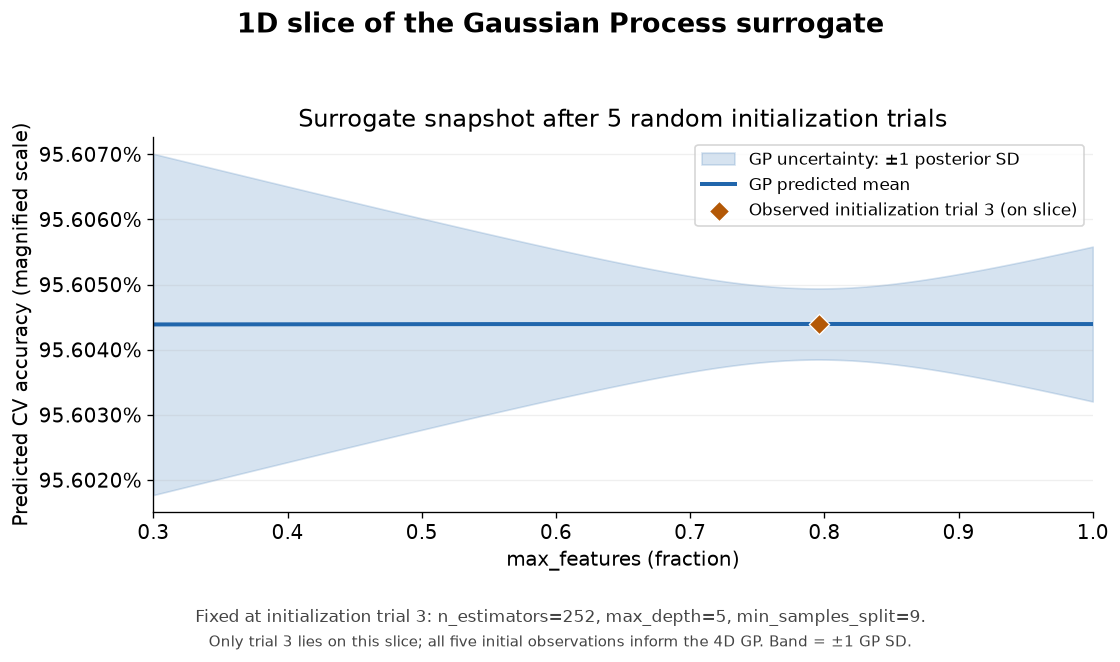

In [10]:
# Reconstruct the pre-EI belief without fitting forests or changing the search.
initial_trials = histories['Bayesian Optimization'][:INIT_POINTS]
assert [r['evaluation'] for r in initial_trials] == [1, 2, 3, 4, 5]
assert all(r['phase'] == 'initialization' for r in initial_trials)
slice_reference = max(initial_trials, key=lambda r: r['cv_mean'])
slice_fixed = {k: slice_reference[k] for k in PARAMETERS if k != 'max_features'}

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Non-float parameters are experimental.*')
    snapshot = BayesianOptimization(
        f=None, pbounds=pbounds,
        acquisition_function=ExpectedImprovement(xi=XI, exploration_decay=None),
        random_state=SEED, verbose=0, allow_duplicate_points=True,
    )
snapshot_widths = [SPACE[k][1] - SPACE[k][0] for k in snapshot.space.keys]
snapshot.set_gp_params(
    kernel=Matern(length_scale=snapshot_widths,
                  length_scale_bounds=(1e-3, 1e4), nu=2.5),
    alpha=1e-6, normalize_y=True, n_restarts_optimizer=5,
)
# The real optimizer draws its entire initialization queue before fitting the GP.
initial_draws = snapshot.random_sample(INIT_POINTS)
for draw, row in zip(initial_draws, initial_trials):
    recorded_params = {k: row[k] for k in PARAMETERS}
    assert validate_params(draw) == recorded_params
    snapshot.register(params=recorded_params, target=row['cv_mean'])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # Matches the optimizer's GP-fitting convention.
    snapshot._gp.fit(snapshot.space.params, snapshot.space.target)
assert snapshot._gp.X_train_.shape == (5, 4)
np.testing.assert_array_equal(snapshot.space.target,
                              [r['cv_mean'] for r in initial_trials])

feature_grid = np.linspace(*SPACE['max_features'][:2], 401)
slice_inputs = np.array([
    snapshot.space.params_to_array({**slice_fixed, 'max_features': value})
    for value in feature_grid
])
slice_mean, slice_std = snapshot._gp.predict(slice_inputs, return_std=True)
on_slice = [r for r in initial_trials if all(r[k] == v for k, v in slice_fixed.items())]
assert [r['evaluation'] for r in on_slice] == [slice_reference['evaluation']]
assert np.isfinite(slice_mean).all() and np.isfinite(slice_std).all()

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.fill_between(feature_grid, slice_mean - slice_std, slice_mean + slice_std,
                color='#2166ac', alpha=0.18, label='GP uncertainty: ±1 posterior SD')
ax.plot(feature_grid, slice_mean, color='#2166ac', lw=2.4, label='GP predicted mean')
ax.scatter([r['max_features'] for r in on_slice], [r['cv_mean'] for r in on_slice],
           s=75, marker='D', color='#b35806', edgecolors='white', linewidths=0.8,
           zorder=3, label='Observed initialization trial 3 (on slice)')
ax.set(xlim=SPACE['max_features'][:2], xlabel='max_features (fraction)',
       ylabel='Predicted CV accuracy (magnified scale)',
       title='Surrogate snapshot after 5 random initialization trials')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='best', fontsize=10)
fig.suptitle('1D slice of the Gaussian Process surrogate',
             fontsize=16, fontweight='bold')
fig.text(0.5, 0.055,
         'Fixed at initialization trial 3: n_estimators=252, max_depth=5, min_samples_split=9.',
         ha='center', fontsize=10, color='#444444')
fig.text(0.5, 0.018,
         'Only trial 3 lies on this slice; all five initial observations inform the 4D GP. Band = ±1 GP SD.',
         ha='center', fontsize=9, color='#444444')
fig.tight_layout(rect=(0, 0.10, 1, 0.94))
fig.savefig(RESULTS / 'gp_surrogate_uncertainty.png', dpi=180, bbox_inches='tight')
plt.show()


## 12. Trial histories
The tables contain all 20 trials per method. Full-precision scores, fold scores, evaluation times, phases, and CV fingerprints are exported to `results/trials.csv`. Repeated configurations, if any, remain visible and count toward the budget. Display rounding never determines the winners.

In [11]:
trials = pd.DataFrame([row for history in histories.values() for row in history])
trials.to_csv(RESULTS / 'trials.csv', index=False)
for method in histories:
    display(Markdown(f'### {method}'))
    columns = ['evaluation', 'phase', *PARAMETERS, 'cv_mean', 'cv_std',
               'eval_seconds', 'best_so_far']
    display(trials.loc[trials.method == method, columns].style.format({
        'cv_mean': '{:.4%}', 'cv_std': '{:.4%}', 'best_so_far': '{:.4%}',
        'max_features': '{:.6f}', 'eval_seconds': '{:.2f}'}).hide(axis='index'))

### Random Search

evaluation,phase,n_estimators,max_depth,min_samples_split,max_features,cv_mean,cv_std,eval_seconds,best_so_far
1,random,72,16,14,0.901019,94.7253%,2.2413%,2.74,94.7253%
2,random,160,3,15,0.365924,94.9451%,1.1207%,3.78,94.9451%
3,random,182,20,15,0.850245,94.9451%,2.1534%,5.20,94.9451%
4,random,241,11,4,0.615270,96.2637%,1.4906%,5.61,96.2637%
5,random,175,9,5,0.750706,95.6044%,1.8388%,2.93,96.2637%
6,random,282,9,17,0.610390,94.9451%,1.4906%,4.89,96.2637%
7,random,163,6,3,0.344672,95.8242%,1.8906%,2.12,96.2637%
8,random,189,18,17,0.742165,94.7253%,1.7582%,3.20,96.2637%
9,random,91,16,15,0.979489,94.7253%,2.2413%,1.73,96.2637%
10,random,138,10,18,0.844868,94.7253%,2.2413%,2.15,96.2637%


### Bayesian Optimization

evaluation,phase,n_estimators,max_depth,min_samples_split,max_features,cv_mean,cv_std,eval_seconds,best_so_far
1,initialization,152,16,12,0.845784,95.1648%,2.1534%,2.51,95.1648%
2,initialization,70,8,20,0.369982,95.3846%,1.8906%,0.87,95.3846%
3,initialization,252,5,9,0.795651,95.6044%,1.8388%,6.54,95.6044%
4,initialization,199,3,13,0.956987,94.7253%,2.2413%,4.85,95.6044%
5,initialization,179,2,13,0.728157,94.0659%,2.4670%,3.08,95.6044%
6,EI,50,6,20,0.469509,94.9451%,1.1207%,1.23,95.6044%
7,EI,157,14,4,0.595634,95.8242%,2.1308%,5.07,95.8242%
8,EI,298,15,4,0.983462,96.0440%,2.1534%,8.76,96.0440%
9,EI,264,16,4,0.908230,95.8242%,2.1308%,5.37,96.0440%
10,EI,199,20,16,0.774575,94.7253%,2.2413%,3.56,96.0440%


## 13. Convergence comparison
The step curves show best CV accuracy after each completed evaluation. Hollow points show individual trial scores. The default baseline is a reference outside both search budgets.

The shaded region covers Bayesian initialization at evaluations 1–5. The marker after evaluation 5 identifies the start of EI-guided search at evaluation 6. The Bayesian lead at evaluations 1–3 therefore arose during random initialization, before the acquisition function selected any trials.

The shared, fixed 85–100% detail view is accompanied by a full 0–100% view. A plateau shows no observed improvement within the available budget; it does not establish a global optimum. The curves alone cannot identify whether an individual EI suggestion primarily reflects exploration or exploitation.

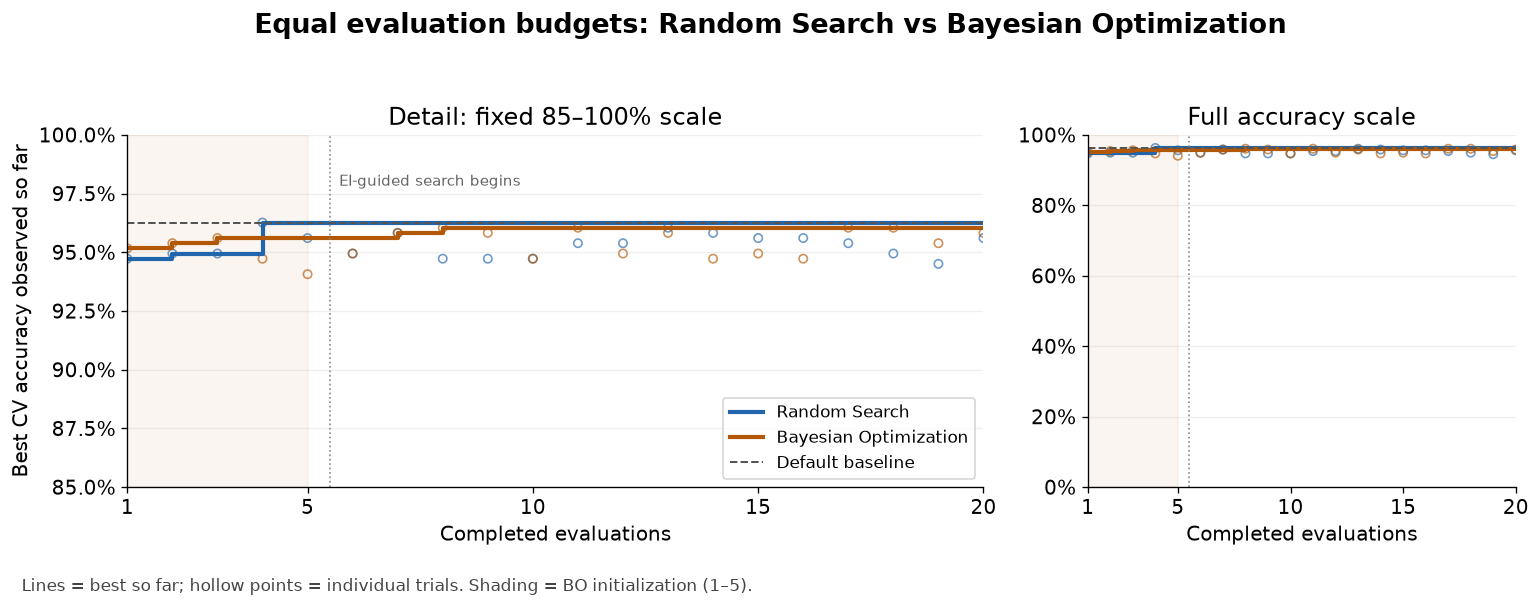

In [12]:
colors = {'Random Search': '#2166ac', 'Bayesian Optimization': '#b35806'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})
for ax in axes:
    for method, history in histories.items():
        h = pd.DataFrame(history)
        ax.step(h.evaluation, h.best_so_far, where='post', lw=2.5,
                color=colors[method], label=method)
        ax.scatter(h.evaluation, h.cv_mean, s=25, facecolors='none',
                   edgecolors=colors[method], alpha=0.65)
    ax.axhline(baseline['cv_mean'], color='#555555', ls='--', lw=1.2,
               label='Default baseline')
    ax.axvspan(1, 5, color='#b35806', alpha=0.06)
    ax.axvline(5.5, color='#888888', ls=':', lw=1)
    ax.set(xlim=(1, 20), xlabel='Completed evaluations')
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis='y', alpha=0.2)
axes[0].set(ylim=(0.85, 1), ylabel='Best CV accuracy observed so far',
            title='Detail: fixed 85–100% scale')
axes[0].yaxis.set_major_locator(MultipleLocator(0.025))
axes[1].set(ylim=(0, 1), title='Full accuracy scale')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].text(5.7, 0.98, 'EI-guided search begins', fontsize=9,
             color='#666666', ha='left', va='center')
fig.suptitle('Equal evaluation budgets: Random Search vs Bayesian Optimization',
             fontsize=16, fontweight='bold')
fig.text(0.02, 0.015, 'Lines = best so far; hollow points = individual trials. Shading = BO initialization (1–5).',
         fontsize=10, color='#444444')
fig.tight_layout(rect=(0, 0.055, 1, 0.94))
fig.savefig(RESULTS / 'convergence.png', dpi=180, bbox_inches='tight')
plt.show()

## 14. Budget efficiency
The 5/10/15/20 checkpoints compare the same number of completed objective evaluations. Reaching one's own maximum sooner is useful context, but it is not enough to establish superior efficiency when the other method reaches a higher score. Compare the actual curves and checkpoint values together. Equal evaluation budgets also need not imply equal wall-clock time.

The Bayesian score at evaluation 5 still reflects initialization only. The 10/15/20 checkpoints include acquisition-guided evaluations.

In [13]:
budget_table = trials[trials.evaluation.isin([5, 10, 15, 20])].pivot(
    index='evaluation', columns='method', values='best_so_far')
budget_table = budget_table[list(histories)]
budget_table.to_csv(RESULTS / 'budget_efficiency.csv')
display(budget_table.style.format('{:.4%}'))

method,Random Search,Bayesian Optimization
evaluation,,
5,96.2637%,95.6044%
10,96.2637%,96.0440%
15,96.2637%,96.0440%
20,96.2637%,96.0440%


## 15. Winner selection
The highest unrounded mean CV accuracy determines each search winner. Python's `max` retains the earliest trial in an exact tie. Both configurations are selected and saved before held-out features are accessed. The final refits read these saved settings, so test results cannot change the chosen hyperparameters.

In [14]:
winner_rows = {method: max(history, key=lambda row: row['cv_mean'])
               for method, history in histories.items()}
winner_params = {method: validate_params({k: row[k] for k in PARAMETERS})
                 for method, row in winner_rows.items()}
selection = {
    'selection_metric': protocol['metric'],
    'winners': {m: {'params': winner_params[m], 'evaluation': row['evaluation'],
                    'cv_mean': row['cv_mean']} for m, row in winner_rows.items()},
}
assert not test_opened
selection_path = RESULTS / 'selected_winners.json'
selection_path.write_text(json.dumps(selection, indent=2), encoding='utf-8')
display(pd.DataFrame([{'Method': m, 'Winning evaluation': row['evaluation'],
                      'CV accuracy': row['cv_mean']} for m, row in winner_rows.items()])
        .style.format({'CV accuracy': '{:.4%}'}).hide(axis='index'))

Method,Winning evaluation,CV accuracy
Random Search,4,96.2637%
Bayesian Optimization,8,96.0440%


## 16. Final evaluation on the untouched test set
Both searches and the baseline are complete before held-out feature rows are accessed. Each final model uses the saved configuration, fits all 455 training samples, and predicts the 114 test samples once. Test accuracy provides final evidence for the fixed experiment and is never used to revise hyperparameters, ranges, seed, or acquisition settings.

In [15]:
assert not test_opened, 'Restart the kernel for a full protocol replay.'
assert all(len(h) == BUDGET for h in histories.values())
assert len(optimizer.res) == BUDGET
saved_selection = json.loads(selection_path.read_text(encoding='utf-8'))
assert saved_selection == selection
test_opened = True
X_test = dataset.data[heldout_ids].copy()
y_test = dataset.target[heldout_ids].copy()

final_params = {'Baseline': {}, **{m: record['params']
                for m, record in saved_selection['winners'].items()}}
final_models, final_metrics = {}, {}
test_calls = {m: 0 for m in final_params}
for method, params in final_params.items():
    model = RandomForestClassifier(random_state=SEED, n_jobs=1, **params)
    started = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - started
    assert all(model.get_params()[k] == v for k, v in params.items())
    predicted = model.predict(X_test)
    test_calls[method] += 1
    final_models[method] = model
    final_metrics[method] = {'test_accuracy': float(accuracy_score(y_test, predicted)),
                             'test_correct': int(np.sum(predicted == y_test)),
                             'test_count': len(y_test), 'fit_seconds': fit_seconds}
display(pd.DataFrame(final_metrics).T[['test_accuracy', 'test_correct', 'test_count']]
        .style.format({'test_accuracy': '{:.4%}', 'test_correct': '{:.0f}',
                       'test_count': '{:.0f}'}))

,test_accuracy,test_correct,test_count
Baseline,95.6140%,109,114
Random Search,95.6140%,109,114
Bayesian Optimization,94.7368%,108,114


## 17. Model size and practicality
We measure **uncompressed pickle protocol 5 bytes divided by 1,000,000** (decimal MB), total decision-tree nodes, tree count, and final fit time. Serialization is measured in memory to avoid delivering unnecessary model files. This size is a storage indicator, not process RAM or prediction latency.

Search wall time includes objective evaluations plus sampling or GP/acquisition work. CV evaluation seconds are summed separately. Both searches run serially in the same environment, Random Search first. Single-run timing is descriptive and can be affected by background load and execution order.

In [16]:
for method, model in final_models.items():
    final_metrics[method].update({
        'model_size_mb': len(pickle.dumps(model, protocol=5)) / 1_000_000,
        'n_estimators': len(model.estimators_),
        'total_nodes': int(sum(tree.tree_.node_count for tree in model.estimators_)),
    })
display(pd.DataFrame(final_metrics).T[
    ['n_estimators', 'total_nodes', 'model_size_mb', 'fit_seconds']]
    .style.format({'n_estimators': '{:.0f}', 'total_nodes': '{:.0f}',
                   'model_size_mb': '{:.3f}', 'fit_seconds': '{:.3f}'}))

,n_estimators,total_nodes,model_size_mb,fit_seconds
Baseline,100,3556,0.314,0.243
Random Search,241,6135,0.561,0.875
Bayesian Optimization,298,7212,0.664,1.598


## 18. Final results
The baseline runtime is its CV evaluation time; search runtimes cover each full 20-evaluation loop. Final refits are timed separately. The displayed CV standard deviation is the variation of the selected trial's five scores, not an uncertainty interval for the search-method difference.

In [17]:
summary_rows = []
for method in final_models:
    row = baseline if method == 'Baseline' else winner_rows[method]
    history = histories.get(method, [])
    cv_seconds = sum(r['eval_seconds'] for r in history) if history else baseline['eval_seconds']
    wall_seconds = search_seconds.get(method, baseline['eval_seconds'])
    actual = final_models[method].get_params()
    summary_rows.append({
        'method': method, 'hyperparameters': {k: actual[k] for k in PARAMETERS},
        'winning_evaluation': row.get('evaluation'), 'cv_mean': row['cv_mean'],
        'cv_std': row['cv_std'], 'cv_evaluation_seconds': cv_seconds,
        'search_or_baseline_seconds': wall_seconds,
        'search_overhead_seconds': max(0, wall_seconds - cv_seconds),
        **final_metrics[method],
    })
summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULTS / 'summary.csv', index=False)

result_columns = ['method', 'cv_mean', 'cv_std', 'test_accuracy',
                  'search_or_baseline_seconds', 'model_size_mb']
display(summary[result_columns].rename(columns={
    'method': 'Model', 'cv_mean': 'CV accuracy', 'cv_std': 'CV SD',
    'test_accuracy': 'Test accuracy', 'search_or_baseline_seconds': 'CV/search (s)',
    'model_size_mb': 'Size (MB)',
}).style.format({'CV accuracy': '{:.4%}', 'CV SD': '{:.4%}',
                 'Test accuracy': '{:.4%}', 'CV/search (s)': '{:.2f}',
                 'Size (MB)': '{:.3f}'}).hide(axis='index'))
display(pd.DataFrame([{'Model': m, **{k: model.get_params()[k] for k in PARAMETERS}}
                      for m, model in final_models.items()]).style
        .format({'max_depth': '{:.0f}',
                 'max_features': lambda v: f'{v:.6f}' if isinstance(v, float) else v},
                na_rep='None')
        .hide(axis='index'))
display(summary[['method', 'cv_evaluation_seconds', 'search_overhead_seconds', 'fit_seconds']]
        .style.format({c: '{:.3f}' for c in ['cv_evaluation_seconds',
                       'search_overhead_seconds', 'fit_seconds']}).hide(axis='index'))

Model,CV accuracy,CV SD,Test accuracy,CV/search (s),Size (MB)
Baseline,96.2637%,1.7855%,95.6140%,1.99,0.314
Random Search,96.2637%,1.4906%,95.6140%,65.22,0.561
Bayesian Optimization,96.0440%,2.1534%,94.7368%,82.56,0.664


Model,n_estimators,max_depth,min_samples_split,max_features
Baseline,100,None,2,sqrt
Random Search,241,11,4,0.615270
Bayesian Optimization,298,15,4,0.983462


method,cv_evaluation_seconds,search_overhead_seconds,fit_seconds
Baseline,1.987,0.000,0.243
Random Search,65.179,0.038,0.875
Bayesian Optimization,74.662,7.894,1.598


### Protocol validation
These assertions verify the completed experiment without additional objective evaluations. Each recorded trial uses the common CV evaluator, bounds, metric, and forest seed. Winner settings are checked against both the trial histories and the final fitted models.

In [18]:
for method, history in histories.items():
    assert len(history) == BUDGET
    assert [r['evaluation'] for r in history] == list(range(1, BUDGET + 1))
    scores = np.array([r['cv_mean'] for r in history])
    curve = np.array([r['best_so_far'] for r in history])
    np.testing.assert_array_equal(curve, np.maximum.accumulate(scores))
    assert np.all(np.diff(curve) >= 0)
    assert winner_rows[method] is history[int(np.argmax(scores))]
    for row in history:
        validate_params({k: row[k] for k in PARAMETERS})
        assert row['fold_fingerprint'] == baseline['fold_fingerprint']
        assert len(row['fold_scores']) == 5
        assert row['cv_mean'] == float(np.mean(row['fold_scores']))
    assert dict(winner_params[method]) == selection['winners'][method]['params']
    assert all(final_models[method].get_params()[k] == v
               for k, v in winner_params[method].items())
for key, (low, high, kind) in SPACE.items():
    assert pbounds[key][:2] == (low, high)
    assert optimizer.space.params_config[key].__class__.__name__ == (
        'IntParameter' if kind is int else 'FloatParameter')
for row, observation in zip(histories['Bayesian Optimization'], optimizer.res):
    assert row['cv_mean'] == observation['target']
    assert validate_params(observation['params']) == {k: row[k] for k in PARAMETERS}
assert optimizer.max['target'] == winner_rows['Bayesian Optimization']['cv_mean']
assert validate_params(optimizer.max['params']) == dict(winner_params['Bayesian Optimization'])
assert sum(r['phase'] == 'initialization' for r in histories['Bayesian Optimization']) == 5
assert sum(r['phase'] == 'EI' for r in histories['Bayesian Optimization']) == 15
assert all(n == 1 for n in test_calls.values())
assert all(final_models[m].get_params()[k] == v
           for m, params in final_params.items() for k, v in params.items())
assert all(m.get_params()['random_state'] == SEED for m in final_models.values())
assert len(trials) == 40

audit = {
    'checks_passed': True, 'candidate_counts': {m: len(h) for m, h in histories.items()},
    'bo_phases': {'initialization': 5, 'EI': 15}, 'cv_fits': 205, 'final_fits': 3,
    'test_predictions_per_model': test_calls, 'fold_fingerprint': fold_fingerprint,
    'exact_duplicate_trials': {m: int(pd.DataFrame(h).duplicated(PARAMETERS).sum())
                               for m, h in histories.items()},
    'warnings': bo_warnings,
}
metrics = {'protocol': protocol, 'environment': environment, 'baseline': baseline,
           'summary': summary_rows, 'audit': audit}
(RESULTS / 'metrics.json').write_text(json.dumps(metrics, indent=2, allow_nan=False), encoding='utf-8')
display(Markdown('**All in-notebook verification checks passed.**'))
display(pd.Series(audit['candidate_counts'], name='Completed evaluations').to_frame())
print('205 CV fits, 3 final fits; 5 initialization + 15 EI; one test prediction per model.')

**All in-notebook verification checks passed.**

,Completed evaluations
Random Search,20
Bayesian Optimization,20


205 CV fits, 3 final fits; 5 initialization + 15 EI; one test prediction per model.


## 19. Interpretation

### Quality
Random Search achieved the strongest tuned CV result: 96.2637%, compared with 96.0440% for Bayesian Optimization. The difference is **0.2198 percentage points**. The baseline matched Random Search in both CV and test accuracy. Both classified 109 of 114 test samples correctly, compared with 108 for Bayesian Optimization. The test difference is therefore one prediction.

### Efficiency
Random Search first found its winning configuration at evaluation 4 and led at evaluations 4–20, including all four budget checkpoints. Bayesian Optimization first reached its maximum at evaluation 8. Its lead at evaluations 1–3 occurred during random initialization, not EI-guided search. Only evaluations 6–20 were acquisition-guided. Bayesian Optimization was not more evaluation-efficient overall in this run. Flat best-so-far curves indicate no further observed gains within the budget, not that the global optimum was found.

### Reliability
The selected trials' CV standard deviations were 1.4906 and 2.1534 percentage points for Random Search and Bayesian Optimization, respectively. These describe fold variation, not statistical significance. Fixed-fold selection can overfit validation results, and the overlapping training folds do not provide independent replications. One seed, one split, and 114 test samples cannot establish general superiority. The different initial random designs also prevent this run from separating initialization luck from the effect of adaptivity.

Strong default performance, relatively broad or flat high-performing regions, and an early random discovery are plausible interpretations, not established causes. Only 15 Bayesian trials were acquisition-guided. The GP approximates a partly stepwise objective and its uncertainty depends on surrogate assumptions. Native integer support remains an experimental package feature; captured warnings are retained with the results.

### Practicality
Bayesian Optimization required more search time and produced the largest selected model. The default forest matched the best observed CV and test accuracy with 100 trees and 3,556 nodes, compared with 241 trees/6,135 nodes for the Random Search winner and 298 trees/7,212 nodes for the Bayesian winner. Its serialized size and final fit time were lower. Thus Random Search was the strongest tuning method in this run, while the default forest was arguably the most practical of the three evaluated models. This comparison does not change the CV-based hyperparameter selections. Further trials could help, but their value remains uncertain and would require a separate protocol.

## 20. Conclusion

Under this dataset, split, search space, seed, CV procedure, metric, and 20-evaluation budget, Random Search achieved the strongest tuned CV accuracy: 96.2637%, versus 96.0440% for Bayesian Optimization. The difference was only 0.2198 percentage points. Random Search and the default forest both achieved 95.6140% test accuracy, while Bayesian Optimization achieved 94.7368%, a difference of one prediction among 114 samples.

Random Search discovered its winning configuration at evaluation 4, compared with evaluation 8 for Bayesian Optimization, and led at every budget checkpoint. Bayesian Optimization's initial lead at evaluations 1–3 came from random initialization. Expected Improvement guided only evaluations 6–20. Bayesian Optimization did not outperform Random Search or show greater overall evaluation efficiency in this run.

Bayesian Optimization required more runtime and produced the largest selected model. The default forest matched the best observed accuracy with fewer trees, lower serialized size, and faster fitting, making it arguably the most practical evaluated model. Strong defaults and an early random discovery are plausible explanations rather than proven causes.

The small score differences, CV variation, and single split and seed limit the evidence. A plateau does not establish a global optimum, and these findings imply no universal superiority of either search strategy. Further evaluations may improve performance, but their practical value remains unproven.

## 21. Conceptual notes

**Model and objective roles:** the Random Forest performs breast-cancer classification from input features. The objective maps a hyperparameter configuration to mean five-fold CV accuracy. The Gaussian Process approximates the relationship between hyperparameters and these observed CV scores.

**Surrogate:** a cheap approximation of the expensive objective. Here the GP regresses from four hyperparameters to measured mean CV accuracy. It is separate from the Random Forest classifier.

**Acquisition function:** a decision rule computed from the surrogate. Its maximizer proposes the next expensive evaluation. It does not measure that candidate's actual CV accuracy.

**Predictive belief:** the GP approximates $f(x)\mid D\sim\mathcal N(\mu(x),\sigma^2(x))$. High mean and low uncertainty suggest a promising region already supported by evidence. Moderate mean and high uncertainty leave room for discovery. This uncertainty is model-dependent and does not guarantee calibrated uncertainty about population performance.

**Exploration vs exploitation:** exploration investigates uncertain or under-tested regions; exploitation investigates predicted high-performing regions. EI combines both signals. We did not save decision-time GP posteriors, so the convergence plot cannot retrospectively classify each suggestion's motive.

Let $f^*$ be the best observed CV score, $\delta=\mu(x)-f^*-\xi$, and $z=\delta/\sigma(x)$ for $\sigma(x)>0$. Here $\Phi$ and $\phi$ are the standard normal CDF and density.

| Rule | Quantity maximized | Next-trial preference |
|:--|:--|:--|
| **Expected Improvement** | $\delta\Phi(z)+\sigma\phi(z)$ | Expected amount of improvement above $f^*+\xi$; accounts for chance and magnitude. |
| **Probability of Improvement** | $\Phi(z)$ | Probability of clearing $f^*+\xi$; can prefer a small likely gain because magnitude is ignored. |
| **Upper Confidence Bound** | $\mu(x)+\kappa\sigma(x)$ | Predicted value plus an explicit uncertainty bonus; larger $\kappa$ gives uncertainty more weight. |

When $\sigma=0$, EI is $\max(\delta,0)$ and PI uses the deterministic threshold comparison. `xi` adjusts an improvement threshold; UCB's `kappa` scales an uncertainty bonus. We executed **EI only**. This experiment provides no evidence about what complete PI or UCB searches would have achieved.

The training's cycle is **Observe → Model → Choose → Update**. Within the package, the GP is refitted when the next suggestion is needed. Registration adds the newest observation to history; a final GP refit is unnecessary for selecting the measured winner.

## 22. References

- *Bayesian Optimization for Hyperparameter Tuning* — training material.
- [scikit-learn Breast Cancer Wisconsin dataset documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).
- [scikit-learn RandomForestClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).
- [Bayesian Optimization (`bayes_opt`) documentation](https://bayesian-optimization.github.io/BayesianOptimization/master/), including [integer parameters](https://bayesian-optimization.github.io/BayesianOptimization/master/parameter_types.html) and the [Expected Improvement API](https://bayesian-optimization.github.io/BayesianOptimization/master/reference/acquisition/ExpectedImprovement.html).